Purpose: Create expression profiles of BPPC/PPC2 in *Y. aloifolia*, *Y. filamentosa*, and *Y. gloriosa* (overall for each species).<br>
Author: Anna Pardo<br>
Date initiated: Jan. 6, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# load time-structured gene information
cinfo = pd.read_csv("./clusters_ngenes_gt_ztgroup_with36-61-43.txt",sep="\t",header="infer")
cinfo.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0.0,319,53_1,5.0
1,2,53,1.0,656,53_2,21.0
2,3,53,1.0,882,53_3,17.0
3,4,53,0.0,1071,53_4,9.0
4,5,53,0.0,428,53_5,21.0


In [3]:
# load CAM gene annotation
cam = pd.read_csv("../degs_downstream/camgenes_Ya_Yf_orthology_synteny.txt",sep="\t",header="infer")

In [4]:
cam.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya
1,Yucal.02G112700.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_2,Ya
2,Yucal.04G001000.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_1,Ya
3,Yucal.07G000800.v2.1,OG0004406,CAM-dark,beta-carbonic anhydrase,bCA5,Ya_bCA5_2,Ya
4,Yucal.03G120900.v2.1,OG0002899,CAM-dark,NAD-dependent malate dehydrogenase (chloroplas...,NAD-MDH-cp,Ya_NAD-MDH-cp_1,Ya


In [5]:
# load TPM data (Yg)
mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")
mdtpm.head()

/tmp/ipykernel_20991/2243598436.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  mdtpm = pd.read_csv("../TPM/Yg_toYgIS_allTPM_correctedmd_over1mil.txt",sep="\t",header="infer")


,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,YufilH1095122m.g,YufilH1095123m.g,YufilH1095125m.g,YufilH1095126m.g,YufilH1095128m.g,YufilH1095131m.g,YufilH1095132m.g,YufilH1095134m.g,YufilH1095146m.g,YufilH1095147m.g
0,Y1,18,1.0,W,1.0,gloriosa,34.002815,4.546167,0.0,17.236119,...,0.000000,6.167441,1.435253,0.279077,11.420139,0.662252,1.886709,6.675105,0.0,0.000000
1,Y10,2AB,1.5,W,3.0,gloriosa,40.070758,3.628454,0.0,14.918115,...,0.713535,2.197522,15.695904,1.193256,10.172780,0.000000,2.214483,12.125756,0.0,0.000000
2,Y100,2AB,6.5,W,23.0,gloriosa,47.402599,5.201760,0.0,17.406497,...,0.314746,2.261806,21.742515,1.798380,10.256681,1.748663,2.075757,25.215640,0.0,1.838780
3,Y101,2AB,1.0,D,1.0,gloriosa,57.062380,6.374324,0.0,10.567561,...,0.000000,1.072366,27.573939,1.164591,9.105769,1.257431,2.431447,4.508369,0.0,0.813682
4,Y103,2AB,1.0,D,1.0,gloriosa,34.679279,6.087451,0.0,11.115252,...,0.000000,0.914550,28.621412,0.869052,7.076224,0.515567,2.419222,4.625880,0.0,0.867418


In [6]:
mdtpm["genotype"] = mdtpm["genotype"].astype(str)
mdtpm["genotype"].unique()

array(['18', '2AB', '1AB', '19', '15', 'Eudy', 'G', '56', '36', '13',
       '45', '52', '43', '37', '48', '55', '70', '61', '51', '46', '53',
       '16', '6', '12', '20', '50'], dtype=object)

In [7]:
zttpm = mdtpm[mdtpm["ZT"].isin([1.0,5.0,9.0,13.0,17.0,21.0])]

In [8]:
# reworked plot_profile() function - to plot profiles by subgenome as well as treatment
def plot_profile(fam,cpdf,axc,a,tf,titletext="Gene Family: ",log=False):
    # pull max TPM (out of curiosity)
    maxtpm = int(round(max(cpdf["TPM"]),0))
    
    # where axc=either a single value or a tuple
    t = np.arange(0,25)
    xthresh = 12
    
    # convert to logTPM if log=True
    if log==True:
        cpdf["logTPM"] = np.log1p(cpdf["TPM"])
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="logTPM",hue="treat",style="subgenome")
    else:
        sns.lineplot(ax=a[axc],data=cpdf,x="ZT",y="TPM",hue="treat",style="subgenome")
    
    lim = a[axc].get_ylim()[1]
    a[axc].fill_between(t,0,lim,where=t>=xthresh,color="gray",alpha=0.3)
    a[axc].set_ylim(0,lim)
    
    a[axc].set_xlim(0,24)
    a[axc].tick_params(axis="both",which="major",labelsize=12)
    a[axc].set_xticks(ticks=list(cpdf["ZT"].unique()))
    a[axc].set_xlabel("")
    a[axc].set_ylabel("TPM from uniquely mapped reads",fontsize=12)
    a[axc].set_title(titletext+fam+" (max TPM: "+str(maxtpm)+")",fontsize=tf)

In [9]:
# rework plottpm similarly
def plottpm_genefamily(tpm,genefam,camdf=cam):
    camfam = camdf[camdf["gene_abbr"]==genefam]
    csgd = {}
    for i in range(len(camfam.index)):
        csgd[camfam.iloc[i,0]] = camfam.iloc[i,6]
    cgenes = [i for i in list(camfam["GeneID"].unique()) if i in tpm.columns]
    cols = ["sample_name","genotype","treat","ZT"]+cgenes
    pwide = tpm[cols]
    plong = pd.melt(pwide,id_vars=["sample_name","genotype","treat","ZT"],value_vars=cgenes)
    plong = plong.rename(columns={"variable":"GeneID","value":"TPM"}).sort_values(by="treat",ascending=False)
    # add subgenome column
    plong["subgenome"] = plong["GeneID"].map(csgd)
    return plong.sort_values(by=["treat","subgenome"],ascending=False)

In [20]:
# set up a column in the 'cam' object stating whether a gene is time-structured or not, 
# and if so, what cluster & ZTpeak is it in? (separate columns)

# to do this: load cluster membership data
# define a function to load & summarize the data for a given genotype
def load_sum_gt(gt):
    if gt in ["all","gt37"]:
        if gt=="all":
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_18-Nov.tsv",sep="\t",header="infer")
        else:
            gtc = pd.read_csv("./hck6_treatonly_"+gt+"_17-Nov.tsv",sep="\t",header="infer")
            gt = "37"
    elif gt in ["Ya","Yf"]:
        gtc = pd.read_csv("./"+gt+"_hclust_k6_clusters.txt",sep="\t",header="infer")
    else:
        gtc = pd.read_csv("./Yg"+gt+"_hclust_k6_clusters.txt",sep="\t",header="infer")
        
    gtc["genotype"] = gt
    # set up a CAM column
    camornot = []
    for i in gtc["GeneID"]:
        if i in camids:
            camornot.append("Y")
        else:
            camornot.append("N")
    gtc["CAM_notCAM"] = camornot
    
    # set up a subgenome column
    sg = []
    for i in gtc["GeneID"]:
        if i.startswith("Yucal"):
            sg.append("Ya")
        else:
            sg.append("Yf")
    gtc["subgenome"] = sg
    
    # set up a genotype_cluster column
    gtc["gtc"] = gtc["genotype"]+"_"+gtc["cluster"].astype(str)
    
    return gtc

In [11]:
camids = list(cam["GeneID"].unique())

In [21]:
dflist = []
for f in os.listdir("./"):
    if f.endswith("k6_clusters.txt"):
        print(f)
        if "Yg" in f:
            gt = f.split("_")[0].lstrip("Yg")
        else:
            gt = f.split("_h")[0]
        print(gt)
        dflist.append(load_sum_gt(gt))
dflist.append(load_sum_gt("gt37"))

YgG_hclust_k6_clusters.txt
G
YgEudy_hclust_k6_clusters.txt
Eudy
Yg36_hclust_k6_clusters.txt
36
Yg43_hclust_k6_clusters.txt
43
Yg13_hclust_k6_clusters.txt
13
Yg45_hclust_k6_clusters.txt
45
Yg19_hclust_k6_clusters.txt
19
Yg51_hclust_k6_clusters.txt
51
Yg2AB_hclust_k6_clusters.txt
2AB
Yg52_hclust_k6_clusters.txt
52
Yg46_hclust_k6_clusters.txt
46
Yg70_hclust_k6_clusters.txt
70
Ya_hclust_k6_clusters.txt
Ya
Yg48_hclust_k6_clusters.txt
48
Yg55_hclust_k6_clusters.txt
55
Yg18_hclust_k6_clusters.txt
18
Yg61_hclust_k6_clusters.txt
61
Yg53_hclust_k6_clusters.txt
53
Yg56_hclust_k6_clusters.txt
56
Yf_hclust_k6_clusters.txt
Yf
Yg1AB_hclust_k6_clusters.txt
1AB


In [22]:
allclusters = pd.concat(dflist)
allclusters.head()

,cluster,GeneID,genotype,CAM_notCAM,subgenome,gtc
0,1,Yucal.01G003400.v2.1,G,N,Ya,G_1
1,1,Yucal.01G004800.v2.1,G,N,Ya,G_1
2,2,Yucal.01G004900.v2.1,G,N,Ya,G_2
3,3,Yucal.01G005300.v2.1,G,N,Ya,G_3
4,4,Yucal.01G012100.v2.1,G,N,Ya,G_4


In [24]:
allclusters["genotype"].unique()

array(['G', 'Eudy', '36', '43', '13', '45', '19', '51', '2AB', '52', '46',
       '70', 'Ya', '48', '55', '18', '61', '53', '56', 'Yf', '1AB', '37'],
      dtype=object)

In [25]:
allclusters = allclusters.merge(cinfo[["gtc","ZTpeak"]],on="gtc",how="left")
allclusters.head()

,cluster,GeneID,genotype,CAM_notCAM,subgenome,gtc,ZTpeak
0,1,Yucal.01G003400.v2.1,G,N,Ya,G_1,1.0
1,1,Yucal.01G004800.v2.1,G,N,Ya,G_1,1.0
2,2,Yucal.01G004900.v2.1,G,N,Ya,G_2,9.0
3,3,Yucal.01G005300.v2.1,G,N,Ya,G_3,5.0
4,4,Yucal.01G012100.v2.1,G,N,Ya,G_4,21.0


In [26]:
# now, merge with the CAM data
# note this is for Yg only
camclust = allclusters[allclusters["CAM_notCAM"]=="Y"]
camclust.head()

,cluster,GeneID,genotype,CAM_notCAM,subgenome,gtc,ZTpeak
229,6,Yucal.02G112700.v2.1,G,Y,Ya,G_6,9.0
338,2,Yucal.03G005000.v2.1,G,Y,Ya,G_2,9.0
527,1,Yucal.04G178900.v2.1,G,Y,Ya,G_1,1.0
854,2,Yucal.07G108400.v2.1,G,Y,Ya,G_2,9.0
855,2,Yucal.07G108500.v2.1,G,Y,Ya,G_2,9.0


In [27]:
camclust["genotype"].unique()

array(['G', 'Eudy', '36', '43', '13', '45', '19', '51', '2AB', '52', '46',
       '70', 'Ya', '48', '55', '18', '61', '53', '56', 'Yf', '1AB', '37'],
      dtype=object)

In [28]:
camts = cam.merge(camclust[["GeneID","subgenome","gtc","ZTpeak"]],on=["GeneID","subgenome"],how="left")

In [29]:
camts.head()

,GeneID,Orthogroup,Pathway,gene_name,gene_abbr,gene_abbr_unique,subgenome,gtc,ZTpeak
0,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,36_6,9.0
1,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,13_2,5.0
2,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,45_5,5.0
3,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,19_4,1.0
4,Yucal.01G165600.v2.1,OG0001578,CAM-dark,beta-carbonic anhydrase,bCA1234,Ya_bCA1234_1,Ya,51_6,1.0


In [30]:
# load parental TPM
yatpm = pd.read_csv("../../rna_reanalysis_30-Jun-2025/TPM/Yalo_TPM_withmd_July2025.txt",sep="\t",header="infer")
yftpm = pd.read_csv("../../rna_reanalysis_30-Jun-2025/TPM/YfilH1_TPM_withmd_July2025.txt",sep="\t",header="infer")

In [31]:
yatpm.head()

,sample_name,genotype,time,treat,ZT,species,Yucal.01G000100.v2.1,Yucal.01G000200.v2.1,Yucal.01G000300.v2.1,Yucal.01G000400.v2.1,...,Yucal.1Z267100.v2.1,Yucal.1Z267200.v2.1,Yucal.1Z267300.v2.1,Yucal.1Z267700.v2.1,Yucal.1Z267800.v2.1,Yucal.1Z268400.v2.1,Yucal.1Z268500.v2.1,Yucal.1Z269100.v2.1,Yucal.1Z269200.v2.1,Yucal.1Z269300.v2.1
0,X39,7.0,1.0,D,1.0,aloifolia,62.000407,19.252242,0.000000,23.591599,...,0.000000,0.637724,28.055165,0.0,16.332481,10.238059,0.0,0.000000,0.000000,0.151888
1,X40,7.0,6.0,D,21.0,aloifolia,51.570207,18.548350,0.000000,23.537506,...,0.058713,0.000000,24.155255,0.0,2.537958,2.380903,0.0,0.168494,0.000000,0.182918
2,X41,7.0,1.0,W,1.0,aloifolia,55.064137,9.433332,0.000000,17.501874,...,0.046340,0.484935,12.500902,0.0,3.305183,3.557022,0.0,0.099741,0.000000,0.202121
3,X42,7.0,6.0,W,21.0,aloifolia,56.178337,11.848237,0.000000,24.823426,...,0.000000,0.000000,22.067065,0.0,7.006344,4.191820,0.0,0.000000,0.000000,0.000000
4,X47,7.0,2.0,D,5.0,aloifolia,57.323927,13.959747,0.322194,28.146879,...,0.064688,0.000000,17.382935,0.0,4.194349,4.777962,0.0,0.092820,0.104495,0.161226


In [32]:
yabppc = plottpm_genefamily(yatpm,"BPPC")

In [33]:
yabppc.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
107,X32,NaN,W,21.0,Yucal.07G108500.v2.1,174.539334,Ya
51,X81,23.0,W,1.0,Yucal.07G108400.v2.1,34.317971,Ya
91,X85,23.0,W,17.0,Yucal.07G108500.v2.1,61.562895,Ya
35,X32,NaN,W,21.0,Yucal.07G108300.v2.1,233.509688,Ya
89,X83,23.0,W,5.0,Yucal.07G108500.v2.1,39.063248,Ya


In [34]:
yfbppc = plottpm_genefamily(yftpm,"BPPC")

In [35]:
yfbppc.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
23,X70,2.0,W,13.0,YufilH1044442m.g,421.096897,Yf
16,X120,9.0,W,5.0,YufilH1044442m.g,145.842070,Yf
44,X35,NaN,W,21.0,YufilH1044442m.g,63.968347,Yf
42,X29,NaN,W,17.0,YufilH1044442m.g,90.653648,Yf
40,X23,NaN,W,13.0,YufilH1044442m.g,104.677172,Yf


In [36]:
ygbppc = plottpm_genefamily(zttpm,"BPPC")

In [37]:
ygbppc.head()

,sample_name,genotype,treat,ZT,GeneID,TPM,subgenome
2613,SRR10663917,51,W,9.0,YufilH1044442m.g,9.934650,Yf
2646,SRR10848722,55,W,21.0,YufilH1044442m.g,1.096940,Yf
2645,SRR10848835,70,W,21.0,YufilH1044442m.g,40.981741,Yf
2644,SRR10848785,61,W,17.0,YufilH1044442m.g,0.938605,Yf
2643,SRR10848724,55,W,17.0,YufilH1044442m.g,1.569799,Yf


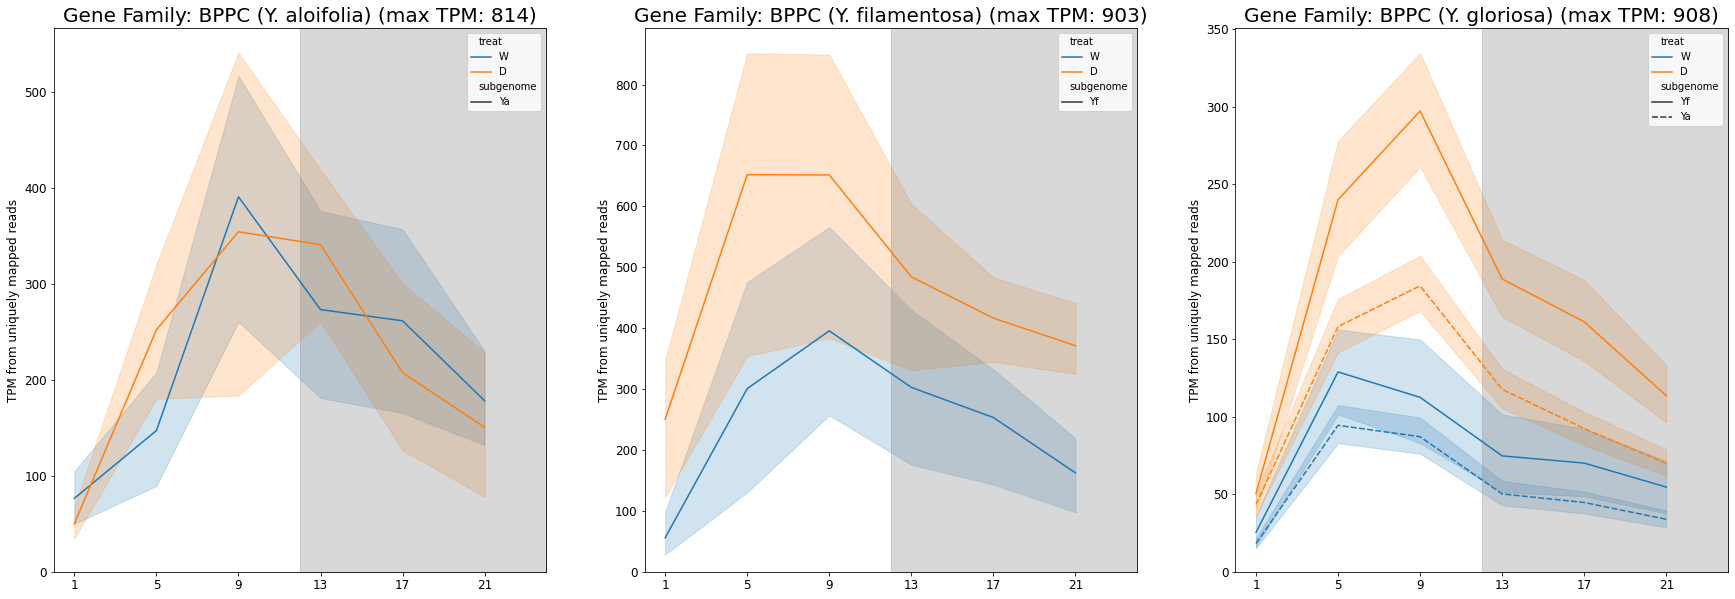

In [45]:
fig,ax = plt.subplots(nrows=1,ncols=3,figsize=(30,10))

plot_profile("BPPC (Y. aloifolia)",yabppc,0,ax,20)
plot_profile("BPPC (Y. filamentosa)",yfbppc,1,ax,20)
plot_profile("BPPC (Y. gloriosa)",ygbppc,2,ax,20)

plt.savefig("./bppc_profiles_all3sp.png",dpi=200,bbox_inches="tight")
plt.savefig("./bppc_profiles_all3sp.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./bppc_profiles_all3sp.svg",dpi=200,bbox_inches="tight")